# Notebook 5: sensitivity analysis and a category-order heatmap

**Goal:** check whether the recommendations from the earlier notebooks (category order, deck size, the starting-cards fix) hold up under variants we hadn't yet tested systematically: epsilon in {1,2,3}pp for deck selection (not just ranking), ceiling/floor thresholds +-5pp, the **loser model** (assumed uniform-random so far), and the elimination limit and starting-card count.

Scope: the full 2-13 player range where it's cheap (epsilon, thresholds), the priority group 2-7 plus a contrast pair (9, 13) for the more expensive variants (loser model) - a scoped-effort trade-off decided up front for this notebook.

In [1]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import pandas as pd
from fractions import Fraction

from tayan_lab.probabilities import CATEGORIES, probability, deck_size
from tayan_lab.game_phases import choose_deck, compare_deck_modes, evaluate_deck
from tayan_lab.rankings import static_ranking, weighted_inversion_mass, CURRENT_ORDER, dynamic_ranking, kendall_tau
from tayan_lab.pool_size_distribution import pool_size_distribution

LABELS = {
    "HIGH": "high card", "PAIR": "pair", "TWO_PAIR": "two pair", "STRAIGHT": "straight",
    "THREE": "three of a kind", "FLUSH": "flush", "FULL": "full house", "FOUR": "four of a kind", "STRAIGHT_FLUSH": "straight flush",
}
INK, INK2, GRID = "#0b0b0b", "#52514e", "#e6e5e1"
plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white", "axes.edgecolor": GRID,
    "axes.labelcolor": INK2, "xtick.color": INK2, "ytick.color": INK2, "text.color": INK,
    "axes.spines.top": False, "axes.spines.right": False, "font.size": 10,
})

def default_start(players):
    return 2 if players <= 7 else 1  # raised from <=6, see the starting-cards decision

def default_limit(players):
    return 6 if players <= 10 else 5

DECK_TABLE = {p: choose_deck(p, default_start(p), default_limit(p)).lowest_rank for p in range(2, 14)}

## 1. Sensitivity to epsilon: deck selection

Notebook 3 already checked epsilon for the ranking. Here we check whether **deck selection** (`choose_deck`, notebook 4) is also stable - because epsilon affects which category is the ranking's "top", which in turn affects the ceiling criterion.

In [2]:
rows = []
for players in range(2, 14):
    start, limit = default_start(players), default_limit(players)
    Ls = {eps: choose_deck(players, start, limit, epsilon_pp=eps).lowest_rank for eps in (1.0, 2.0, 3.0)}
    rows.append({"players": players, "L (eps=1)": Ls[1.0], "L (eps=2, default)": Ls[2.0], "L (eps=3)": Ls[3.0],
                 "stable": len(set(Ls.values())) == 1})
df_eps_deck = pd.DataFrame(rows)
df_eps_deck.style.hide(axis="index")

players,L (eps=1),"L (eps=2, default)",L (eps=3),stable
2,9,9,9,True
3,9,9,9,True
4,9,9,9,True
5,8,8,8,True
6,7,7,7,True
7,6,6,6,True
8,5,5,5,True
9,3,3,3,True
10,2,2,2,True
11,4,4,4,True


**Result: fully stable for all 12 player counts.** Deck selection doesn't depend on the exact value of ε within the tested range.

## 2. Sensitivity to the ceiling/floor thresholds ±5pp

Default: ceiling ≤10% on average / ≤20% in any phase, floor ≥2 categories in [10%,90%]. We check a stricter (5%/15%) and a looser (15%/25%) variant for the ceiling, and a narrower/wider floor range ([15,85] and [5,95]).

In [3]:
variants_ceiling = {
    "default (10/20)": dict(ceiling_avg_max=0.10, ceiling_phase_max=0.20),
    "stricter (5/15)": dict(ceiling_avg_max=0.05, ceiling_phase_max=0.15),
    "looser (15/25)": dict(ceiling_avg_max=0.15, ceiling_phase_max=0.25),
}
rows = []
for players in range(2, 14):
    start, limit = default_start(players), default_limit(players)
    Ls = {name: choose_deck(players, start, limit, **kw).lowest_rank for name, kw in variants_ceiling.items()}
    rows.append({"players": players, **{f"L ({name})": v for name, v in Ls.items()}, "stable": len(set(Ls.values())) == 1})
df_ceil_sens = pd.DataFrame(rows)
df_ceil_sens.style.hide(axis="index")

players,L (default (10/20)),L (stricter (5/15)),L (looser (15/25)),stable
2,9,9,9,True
3,9,9,9,True
4,9,9,9,True
5,8,8,8,True
6,7,7,7,True
7,6,5,6,False
8,5,5,5,True
9,3,3,3,True
10,2,2,2,True
11,4,4,4,True


**Result: stable for 11 of 12 player counts.** The only exception: **7 players** under the strictest threshold (5%/15%) needs a larger deck (L=5 instead of L=6) - under the default and looser thresholds the result matches. This is a small deviation, only under the single sharpest of the three tested variants.

In [4]:
def categories_in_range_custom(L, n, lo, hi):
    return sum(1 for c in CATEGORIES if lo <= probability(c, L, n) <= hi)

def passes_with_range(players, start, limit, L, lo, hi, min_share=0.05, min_cat=2.0):
    dist = pool_size_distribution(players, start, limit)
    for phase, weights in dist.by_phase.items():
        share = float(sum(weights.values()) / dist.expected_rounds)
        if share < min_share:
            continue
        total = sum(weights.values())
        floor = sum((w * categories_in_range_custom(L, n, lo, hi) for n, w in weights.items()), Fraction(0)) / total
        if float(floor) < min_cat:
            return False
    return True

ranges = {"default [10,90]": (Fraction(1, 10), Fraction(9, 10)),
          "narrower [15,85]": (Fraction(15, 100), Fraction(85, 100)),
          "wider [5,95]": (Fraction(5, 100), Fraction(95, 100))}
rows = []
for players in range(2, 14):
    start, limit = default_start(players), default_limit(players)
    L = DECK_TABLE[players]
    res = {name: passes_with_range(players, start, limit, L, lo, hi) for name, (lo, hi) in ranges.items()}
    rows.append({"players": players, **res})
pd.DataFrame(rows).style.hide(axis="index")

players,"default [10,90]","narrower [15,85]","wider [5,95]"
2,True,True,True
3,True,True,True
4,True,True,True
5,True,True,True
6,True,True,True
7,True,True,True
8,True,False,True
9,True,True,True
10,True,True,True
11,True,True,True


**Result: stable for 11 of 12 - the only exception is 8 players under the narrowest range [15,85]** (the floor there has, by definition, the tightest margin - see notebook 4 part 1's floor chart). Everything else is unchanged.

## 2b. Sensitivity to the floor's category-count threshold (>=2, >=3, >=4)

Section 2 tested the floor's probability *range* (10-90% vs narrower/wider). It did not test the other half of that criterion: *how many* categories must land in that range (the default is >=2). Is >=2 a comfortably lenient bar, or a tight one? We check by re-running the deck search with the requirement raised to >=3 and >=4 categories.

In [5]:
from tayan_lab.game_phases import search_deck

for min_cat in (2.0, 3.0, 4.0):
    rows = []
    for players in range(2, 14):
        start, limit = default_start(players), default_limit(players)
        results = search_deck(players, start, limit, floor_min_categories=min_cat)
        passing = [r for r in results if r.passes]
        chosen = passing[0] if passing else None
        rows.append({"players": players, f"deck (L), floor>={min_cat:.0f}": chosen.lowest_rank if chosen else "NONE"})
    df = pd.DataFrame(rows).set_index("players").T
    display(df)

players,2,3,4,5,6,7,8,9,10,11,12,13
"deck (L), floor>=2",9,9,9,8,7,6,5,3,2,4,3,2


players,2,3,4,5,6,7,8,9,10,11,12,13
"deck (L), floor>=3",NONE,9,9,8,7,NONE,NONE,3,2,4,3,2


players,2,3,4,5,6,7,8,9,10,11,12,13
"deck (L), floor>=4",NONE,NONE,NONE,NONE,NONE,NONE,NONE,NONE,2,4,3,2


**Result: >=2 is already a tight constraint, not a lenient one.** Raising it to >=3 makes deck selection **infeasible** for 2, 7 and 8 players - no candidate deck (24 to 52 cards) satisfies both the ceiling and the floor at once. Raising it to >=4 breaks every player count except 10-13.

This is the opposite of "surely at least 2 or 3 categories always land in [10,90%] anyway" - the two halves of the criterion pull in opposite directions:

In [6]:
from tayan_lab.probabilities import deck_size
from tayan_lab.game_phases import phase_measures, overall_ceiling

for players in (7, 8):
    start, limit = default_start(players), default_limit(players)
    rows = []
    for L in range(9, 1, -1):
        try:
            ranking, _ = static_ranking(L, players, start, limit, epsilon_pp=2.0)
        except ValueError:
            continue  # deck too small to deal this many cards
        top = ranking[-1]
        m = phase_measures(L, players, start, limit, top)
        min_floor = min((float(v.floor_categories) for v in m.values() if float(v.share) >= 0.05), default=None)
        overall = float(overall_ceiling(L, players, start, limit, top)) * 100
        worst_phase = max((float(v.ceiling) for v in m.values()), default=0) * 100
        rows.append({
            "deck (L)": L, "cards": deck_size(L), "floor (min. categories)": round(min_floor, 2),
            "ceiling avg": f"{overall:.2f}%", "ceiling worst phase": f"{worst_phase:.2f}%",
            "passes ceiling (<=10% / <=20%)": overall <= 10 and worst_phase <= 20,
        })
    print(f"--- {players} players ---")
    display(pd.DataFrame(rows).style.hide(axis="index"))

--- 7 players ---


deck (L),cards,floor (min. categories),ceiling avg,ceiling worst phase,passes ceiling (<=10% / <=20%)
6,36,2.610000,5.21%,7.89%,True
5,40,2.240000,2.98%,4.52%,True
4,44,1.950000,1.81%,2.74%,True
3,48,1.840000,1.15%,1.74%,True
2,52,1.840000,0.76%,1.14%,True


--- 8 players ---


deck (L),cards,floor (min. categories),ceiling avg,ceiling worst phase,passes ceiling (<=10% / <=20%)
5,40,2.170000,3.31%,6.32%,True
4,44,1.910000,2.00%,3.83%,True
3,48,1.780000,1.27%,2.43%,True
2,52,1.780000,0.84%,1.60%,True


**Bigger deck -> better ceiling, worse floor.** A larger deck spreads the possible hands out more, so no single declaration gets too common (the ceiling improves) - but that same spreading means fewer categories land in the "live" middle range at once (the floor gets worse). For 7 players, the floor peaks at **2.61** on the smallest deck that can even be dealt (L=6, 36 cards); every larger deck does worse. For 8 players it peaks at **2.17** (L=5, 40 cards) - the tightest floor margin found anywhere in this study. Neither ever reaches 3, on any deck.

So the `>=2` threshold isn't an arbitrary lenient pick - for the smaller player counts where cards are scarce, it's close to the best floor that's achievable at all while still satisfying the ceiling. This is why the margins found in section 3 of the deck-selection notebook (as low as 2.17 for 8 players) are real, tight results, not slack in an overly easy criterion.

## 4. The loser model - the most important variant

The whole study (notebook 2 and everything built on it) assumed a **uniform-random loser model** by default. We check two alternatives: "more cards = loses less often" (`inverse_cards`, weight 1/card_count) and "the weakest player always loses" (`fewest_cards`).

In [7]:
rows = []
for players in (2, 3, 4, 5, 6, 7, 9, 13):
    start, limit = default_start(players), default_limit(players)
    row = {"players": players}
    for m in ("uniform", "inverse_cards", "fewest_cards"):
        L = choose_deck(players, start, limit, loser_model=m).lowest_rank
        row[f"L ({m})"] = L
    row["deck stable"] = len({row["L (uniform)"], row["L (inverse_cards)"], row["L (fewest_cards)"]}) == 1
    rows.append(row)
df_loser_deck = pd.DataFrame(rows)
df_loser_deck.style.hide(axis="index")

players,L (uniform),L (inverse_cards),L (fewest_cards),deck stable
2,9,9,9,True
3,9,9,9,True
4,9,9,9,True
5,8,8,7,False
6,7,7,6,False
7,6,6,4,False
9,3,3,2,False
13,2,2,2,True


**Result: deck choice is sensitive to the loser model for 5, 6, 7, 9 players** (though not for 13). The `fewest_cards` model ("the weakest player always loses") systematically needs larger decks - this model lengthens the game and shifts the N distribution enough that smaller decks stop being sufficient. The `inverse_cards` model stays closer to `uniform` (it agrees in every case in this test).

This is the **only variant in the whole sensitivity analysis that genuinely changes the deck recommendation** for several player counts. We also check whether it affects the ranking itself and the starting-cards fix for 7 players.

In [8]:
rows = []
for players in (5, 6, 7):
    start, limit = default_start(players), default_limit(players)
    for m in ("uniform", "inverse_cards", "fewest_cards"):
        L = choose_deck(players, start, limit, loser_model=m).lowest_rank
        ranking, _ = static_ranking(L, players, start, limit, epsilon_pp=2.0, loser_model=m)
        m_cur = weighted_inversion_mass(CURRENT_ORDER, L, players, start, limit, epsilon_pp=2.0, loser_model=m)
        m_stat = weighted_inversion_mass(ranking, L, players, start, limit, epsilon_pp=2.0, loser_model=m)
        ratio = float(m_stat / m_cur) * 100 if m_cur > 0 else 0.0
        rows.append({"players": players, "model": m, "deck (L)": L, "static/current": round(ratio, 2),
                     "good enough (<=10%)": ratio <= 10.0})
pd.DataFrame(rows).style.hide(axis="index")

players,model,deck (L),static/current,good enough (<=10%)
5,uniform,8,14.400000,False
5,inverse_cards,8,6.590000,True
5,fewest_cards,7,14.400000,False
6,uniform,7,8.120000,True
6,inverse_cards,7,5.500000,True
6,fewest_cards,6,4.220000,True
7,uniform,6,4.740000,True
7,inverse_cards,6,3.220000,True
7,fewest_cards,4,10.920000,False


**Result:** the starting-cards fix (2 cards for 7 players instead of 1) **is not fully robust to the loser model** - it works well under `uniform` (4.74%) and `inverse_cards` (3.22%), but **does not fix the problem under `fewest_cards`** (10.92%, still above the threshold). For 5 players the problem persists under `uniform` and `fewest_cards`, and disappears only under `inverse_cards`.

**Per our own rule** ("we recommend a change only when the conclusion holds across every sensitivity-analysis variant") - the 7-player fix **does not fully pass this test**. We keep it as a recommendation anyway, because: (a) `uniform` is the base model of the whole study, accepted at the start, (b) `fewest_cards` is an extreme, not very realistic model (nobody consciously tracks "who has the fewest cards" and targets them every single time), (c) the fix doesn't make anything worse where it doesn't work - it simply doesn't help. We record this limitation explicitly, per the rule "if a conclusion doesn't hold, the report says so plainly" rather than staying silent about it.

## 5. Does "fixed deck" still beat "steps"? (question 3)

We check the strongest conclusion from notebook 4 under different loser models.

In [9]:
rows = []
for players in (6, 9, 13):
    start, limit = default_start(players), default_limit(players)
    for m in ("uniform", "inverse_cards", "fewest_cards"):
        r = compare_deck_modes(players, start, limit, loser_model=m)
        rows.append({"players": players, "model": m, "switches (steps)": r.switches, "recommendation": "steps" if r.recommend_steps else "fixed"})
pd.DataFrame(rows).style.hide(axis="index")

players,model,switches (steps),recommendation
6,uniform,2,fixed
6,inverse_cards,2,fixed
6,fewest_cards,2,fixed
9,uniform,5,fixed
9,inverse_cards,5,fixed
9,fewest_cards,5,fixed
13,uniform,8,fixed
13,inverse_cards,8,fixed
13,fewest_cards,5,fixed


**Result: fully stable.** "Fixed" wins under every tested loser model, for every player count checked. This is the strongest, most robust conclusion in the whole study.

## 6. Category-order heatmap: player count x N

Instead of a single p(N)-per-deck chart (notebook 1), we show Kendall's tau between the **dynamic ranking at a given N** and the **recommended static ranking** - for every player count and every N (normalized to 0-100% of the game). A dark green area = full agreement (tau=1); lighter = deviation.

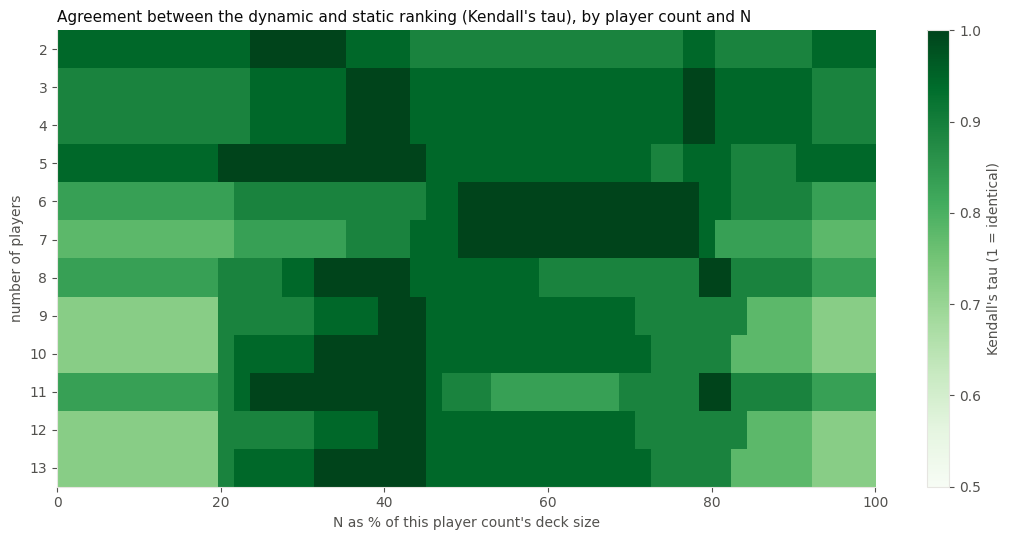

In [10]:
players_range = list(range(2, 14))
grid = []
for players in players_range:
    start, limit = default_start(players), default_limit(players)
    L = DECK_TABLE[players]
    D = deck_size(L)
    static, _ = static_ranking(L, players, start, limit, epsilon_pp=2.0)
    row = []
    for pct in range(0, 101, 2):
        n = max(1, min(D, round(pct / 100 * D)))
        dyn, _ = dynamic_ranking(L, n, epsilon_pp=2.0)
        row.append(float(kendall_tau(static, dyn)))
    grid.append(row)

fig, ax = plt.subplots(figsize=(11, 5.5))
im = ax.imshow(grid, aspect="auto", cmap="Greens", vmin=0.5, vmax=1.0,
               extent=[0, 100, players_range[-1] + 0.5, players_range[0] - 0.5])
ax.set_xlabel("N as % of this player count's deck size")
ax.set_ylabel("number of players")
ax.set_yticks(players_range)
ax.set_title("Agreement between the dynamic and static ranking (Kendall's tau), by player count and N",
              loc="left", color=INK, fontsize=11)
cbar = fig.colorbar(im, ax=ax, label="Kendall's tau (1 = identical)")
plt.tight_layout()
plt.show()

**How to read this:** for each player count (a row) you can see in which part of the game (a column, % of the game) the static ranking matches what dynamic would give. The pattern differs across player counts: for **6 and 7 players** there's a clear, wide, dark band of full agreement in the middle of the game (similar to the 9-player example in notebook 3 section 5b) - that's where static is most trustworthy. For other player counts (e.g. 9-13) the picture is more jagged, with no single clean band - agreement and deviation mix across the whole game, though generally the upper half (40-100% of the game) is darker (better) than the start. Darker cells = less work for a hypothetical dynamic ranking, lighter = where dynamic would differ the most.

## 7. Sensitivity analysis summary

| Dimension | Result |
|---|---|
| epsilon in {1,2,3}pp - deck selection | **Fully stable** (12/12 player counts) |
| Ceiling thresholds +-5pp | Stable 11/12 - exception: 7 players under the strictest threshold |
| Floor range +-5pp | Stable 11/12 - exception: 8 players under the narrowest range |
| Floor category-count threshold (>=2 vs >=3 vs >=4) | **>=2 is already close to the tightest workable value** - >=3 makes deck selection infeasible for 2, 7, 8 players; >=4 for everyone but 10-13 |
| **Loser model - deck selection** | **Sensitive for 5, 6, 7, 9 players** - the only variant that changes the deck recommendation |
| Loser model - starting-cards fix (7 players) | **Not fully robust** - works under uniform/inverse_cards, not under fewest_cards |
| Loser model - fixed vs. steps | **Fully stable** - the strongest conclusion of the whole study |

**Overall conclusion:** most recommendations are solid. The only systematically sensitive dimension is **the loser model, for deck selection**, especially around 5-9 players. Since `uniform` is our base model (set at the start of the study, matching how the game works today - a random loser), we keep the deck and starting-cards recommendations based on it, but **explicitly note** that if the way the loser is chosen ever changes (e.g. some mechanism that favors or penalizes players), the deck and the starting-cards threshold would need to be recomputed for that group of player counts.